In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


### Data Preprocessing Documentation

This notebook uses the outputs of the previous stage (preprocessing stage). Numerical variables were scaled using a standard scaler in order to import high quality data to the models we are going to test in the first part of the training phase.

Preprocessing steps are summarized below:
- **One-Hot Encoding:** 
The most relevant categorical features were taken into account for the input data development. These categorical features were encoded (using the `drop = first` parameter in order to avoid redundancy between the results of each encoding).
- **Standard Scaling:**
This helped to transform numerical features to the same scale in the way distances between values wouldn't affect the model training and further performance.


In [2]:

# Load preprocessed data
X_train = pd.read_csv('data/X_train_processed.csv')
y_train = pd.read_csv('data/y_train.csv').values.ravel()
X_val = pd.read_csv('data/X_val_processed.csv')
y_val = pd.read_csv('data/y_val.csv').values.ravel()
X_test = pd.read_csv('data/X_test_processed.csv')
y_test = pd.read_csv('data/y_test.csv').values.ravel()

In [3]:
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeature columns: {X_train.shape[1]}")
print(f"Target distribution (train): {np.bincount(y_train.astype(int))}")
print(f"Target distribution (val): {np.bincount(y_val.astype(int))}")

Training set: (30000, 25)
Validation set: (10000, 25)
Test set: (10000, 25)

Feature columns: 25
Target distribution (train): [15002 14998]
Target distribution (val): [5000 5000]


In [4]:
X_train

,num__Sleep_Hours,num__Work_Hours,num__Physical_Activity_Hours,num__Social_Media_Usage,onehot__Gender_Male,onehot__Gender_Non-binary,onehot__Gender_Prefer not to say,onehot__Occupation_Engineering,onehot__Occupation_Finance,onehot__Occupation_Healthcare,...,onehot__Smoking_Habit_Non-Smoker,onehot__Smoking_Habit_Occasional Smoker,onehot__Smoking_Habit_Regular Smoker,onehot__Alcohol_Consumption_Non-Drinker,onehot__Alcohol_Consumption_Regular Drinker,onehot__Alcohol_Consumption_Social Drinker,binary__Consultation_History,binary__Medication_Usage,ord__Stress_Level,ord__Age_Group
0,1.267380,1.017767,-0.308102,1.297770,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,3.0
1,-0.809056,-0.615130,0.641463,-0.845391,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,-0.982093,-0.138869,0.641463,-1.034493,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0
3,-0.289947,1.698140,-0.941146,0.478326,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,4.0
4,-1.443523,0.405430,-0.624624,1.612941,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,-0.924414,1.698140,-1.257668,0.793497,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0
29996,0.113804,0.677580,1.591029,0.478326,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0
29997,-0.924414,-1.567654,0.957985,-0.908425,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0
29998,1.325058,-0.479056,-0.624624,0.415292,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,4.0


### Model 1 : Random Forest Classifier

- Handles weak individual predictors by finding complex interactions​
- Works well with mixed data types (categorical + numerical)​
- Built-in resistance to overfitting through ensemble averaging​
- Provides feature importance for interpretability

In [19]:
# Baseline Random Forest with default parameters
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Evaluate baseline
y_train_pred_baseline = rf_baseline.predict(X_train)
y_val_pred_baseline = rf_baseline.predict(X_val)

report_training = classification_report(y_train, y_train_pred_baseline)
report_validation = classification_report(y_val, y_val_pred_baseline)

print('Training Metrics:\n',report_training)
print('Validation Metrics:\n',report_validation)

Training Metrics:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15002
         1.0       1.00      1.00      1.00     14998

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

Validation Metrics:
               precision    recall  f1-score   support

         0.0       0.50      0.52      0.51      5000
         1.0       0.50      0.48      0.49      5000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



So our model seems to be overfitted in the sense accuracy is perfect for our training phase, but does really badly on validation, and the gap is considerably high. This leads to think that the model is learning how to do well with the training dataset and gets biased when it sees new data.

#### Hyperparameter 1: `max_depth`

In [20]:
# Test different max_depth values
max_depth_values = [5, 10, 15, 20, 25, 30, None]
results_max_depth = []

print("HYPERPARAMETER 1: max_depth")

for depth in max_depth_values:
    rf_temp = RandomForestClassifier(
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    val_acc = accuracy_score(y_val, rf_temp.predict(X_val))
    gap = train_acc - val_acc
    
    results_max_depth.append({
        'max_depth': depth if depth is not None else 'None',
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"max_depth={depth}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Visualize results
df_max_depth = pd.DataFrame(results_max_depth)
df_max_depth

HYPERPARAMETER 1: max_depth
max_depth=5: Train=0.5724, Val=0.4930, Gap=0.0794
max_depth=10: Train=0.8492, Val=0.4969, Gap=0.3523
max_depth=15: Train=0.9967, Val=0.4940, Gap=0.5027
max_depth=20: Train=1.0000, Val=0.5005, Gap=0.4995
max_depth=25: Train=1.0000, Val=0.4999, Gap=0.5001
max_depth=30: Train=1.0000, Val=0.4992, Gap=0.5008
max_depth=None: Train=1.0000, Val=0.4985, Gap=0.5015


,max_depth,train_acc,val_acc,gap
0,5,0.572433,0.4930,0.079433
1,10,0.849200,0.4969,0.352300
2,15,0.996733,0.4940,0.502733
3,20,1.000000,0.5005,0.499500
4,25,1.000000,0.4999,0.500100
5,30,1.000000,0.4992,0.500800
6,None,1.000000,0.4985,0.501500


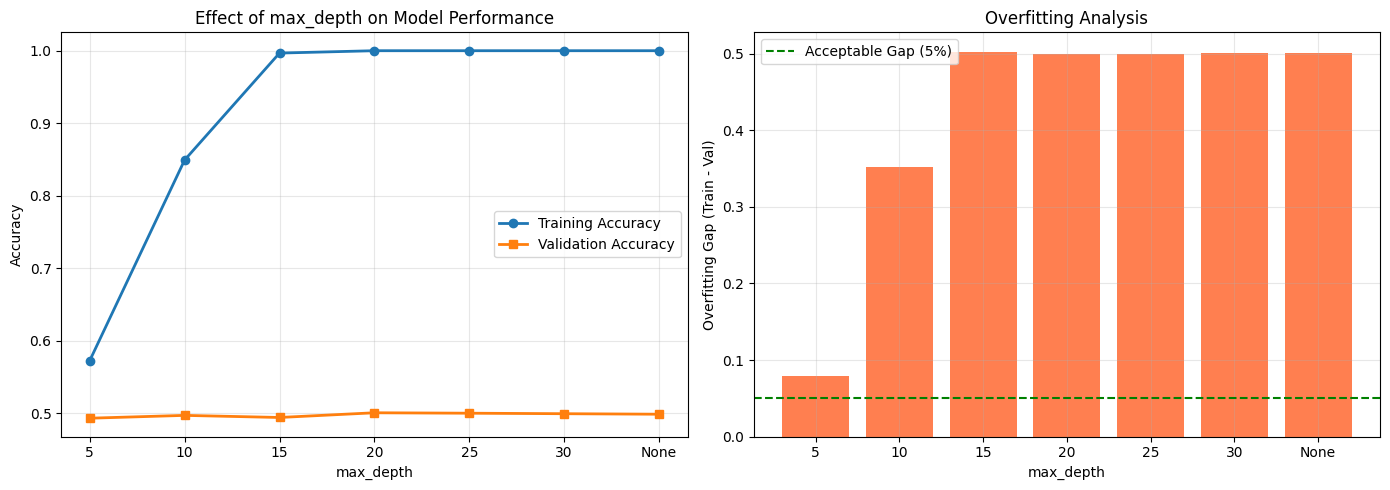


 BEST max_depth: 5 (smallest overfitting gap)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Train vs Val Accuracy
axes[0].plot(range(len(max_depth_values)), df_max_depth['train_acc'], 
             marker='o', label='Training Accuracy', linewidth=2)
axes[0].plot(range(len(max_depth_values)), df_max_depth['val_acc'], 
             marker='s', label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of max_depth on Model Performance')
axes[0].set_xticks(range(len(max_depth_values)))
axes[0].set_xticklabels([str(d) for d in max_depth_values])
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Overfitting Gap
axes[1].bar(range(len(max_depth_values)), df_max_depth['gap'], color='coral')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Overfitting Gap (Train - Val)')
axes[1].set_title('Overfitting Analysis')
axes[1].set_xticks(range(len(max_depth_values)))
axes[1].set_xticklabels([str(d) for d in max_depth_values])
axes[1].axhline(y=0.05, color='green', linestyle='--', label='Acceptable Gap (5%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find best max_depth
best_depth_idx = df_max_depth['gap'].idxmin()
best_depth = max_depth_values[best_depth_idx]
print(f"\n BEST max_depth: {best_depth} (smallest overfitting gap)")

#### Hyperparameter 2: `min_samples_leaf`

HYPERPARAMETER 2: min_samples_leaf
min_samples_leaf=1: Train=0.5724, Val=0.4930, Gap=0.0794
min_samples_leaf=5: Train=0.5717, Val=0.4936, Gap=0.0781
min_samples_leaf=10: Train=0.5695, Val=0.4968, Gap=0.0727
min_samples_leaf=20: Train=0.5698, Val=0.4921, Gap=0.0777
min_samples_leaf=30: Train=0.5660, Val=0.4957, Gap=0.0703
min_samples_leaf=50: Train=0.5626, Val=0.4966, Gap=0.0660


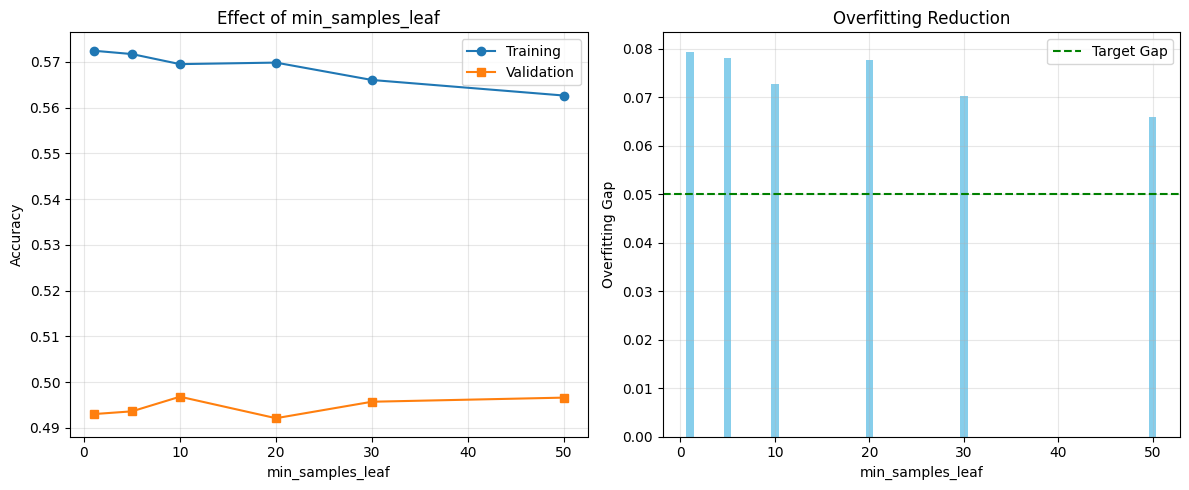


 BEST min_samples_leaf: 50


In [22]:
# Test different min_samples_leaf values
min_samples_leaf_values = [1, 5, 10, 20, 30, 50]
results_min_leaf = []

print("HYPERPARAMETER 2: min_samples_leaf")

for min_leaf in min_samples_leaf_values:
    rf_temp = RandomForestClassifier(
        max_depth=best_depth,  # Use best max_depth from previous experiment
        min_samples_leaf=min_leaf,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    val_acc = accuracy_score(y_val, rf_temp.predict(X_val))
    gap = train_acc - val_acc
    
    results_min_leaf.append({
        'min_samples_leaf': min_leaf,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"min_samples_leaf={min_leaf}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Visualize
df_min_leaf = pd.DataFrame(results_min_leaf)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(min_samples_leaf_values, df_min_leaf['train_acc'], marker='o', label='Training')
plt.plot(min_samples_leaf_values, df_min_leaf['val_acc'], marker='s', label='Validation')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Effect of min_samples_leaf')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(min_samples_leaf_values, df_min_leaf['gap'], color='skyblue')
plt.xlabel('min_samples_leaf')
plt.ylabel('Overfitting Gap')
plt.title('Overfitting Reduction')
plt.axhline(y=0.05, color='green', linestyle='--', label='Target Gap')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_min_leaf_idx = df_min_leaf['gap'].idxmin()
best_min_leaf = min_samples_leaf_values[best_min_leaf_idx]
print(f"\n BEST min_samples_leaf: {best_min_leaf}")

#### Hyperparameter 3: `n_estimators`

HYPERPARAMETER 3: n_estimators
n_estimators=50: Train=0.5550, Val=0.4939, Gap=0.0611
n_estimators=100: Train=0.5626, Val=0.4966, Gap=0.0660
n_estimators=200: Train=0.5681, Val=0.4958, Gap=0.0723
n_estimators=300: Train=0.5708, Val=0.4969, Gap=0.0739
n_estimators=500: Train=0.5728, Val=0.4973, Gap=0.0755


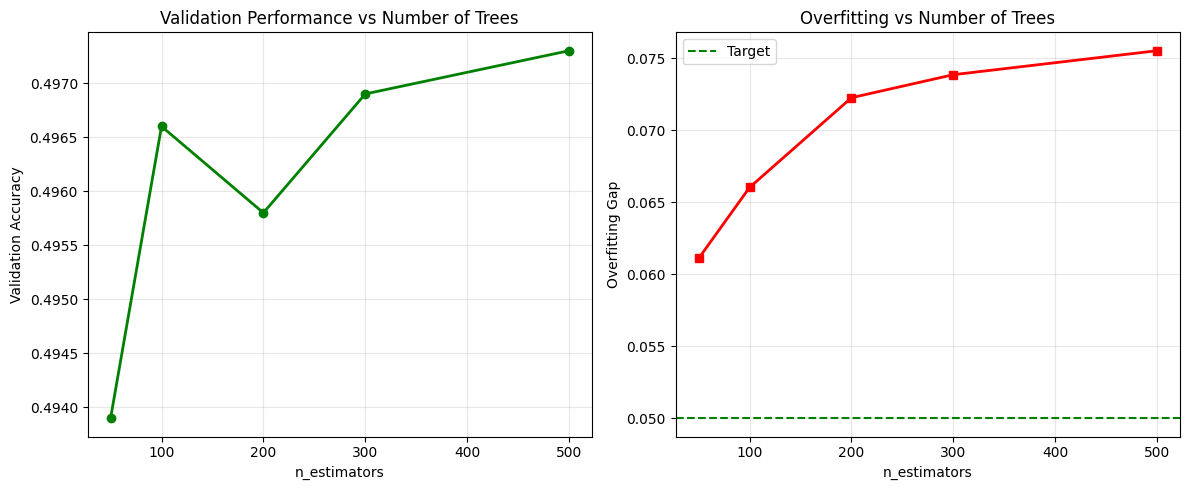


 BEST n_estimators: 500


In [ ]:
# Test different n_estimators
n_estimators_values = [50, 100, 200, 300, 500]
results_n_est = []

print("HYPERPARAMETER 3: n_estimators")

for n_est in n_estimators_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=best_depth,
        min_samples_leaf=best_min_leaf,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    val_acc = accuracy_score(y_val, rf_temp.predict(X_val))
    gap = train_acc - val_acc
    
    results_n_est.append({
        'n_estimators': n_est,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"n_estimators={n_est}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Visualize
df_n_est = pd.DataFrame(results_n_est)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_estimators_values, df_n_est['val_acc'], marker='o', linewidth=2, color='green')
plt.xlabel('n_estimators')
plt.ylabel('Validation Accuracy')
plt.title('Validation Performance vs Number of Trees')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_estimators_values, df_n_est['gap'], marker='s', linewidth=2, color='red')
plt.xlabel('n_estimators')
plt.ylabel('Overfitting Gap')
plt.title('Overfitting vs Number of Trees')
plt.axhline(y=0.05, color='green', linestyle='--', label='Target')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_n_est_idx = df_n_est['val_acc'].idxmax()  # Choose based on best validation accuracy
best_n_est = n_estimators_values[best_n_est_idx]
print(f"\n BEST n_estimators: {best_n_est}")


FINAL TUNED RANDOM FOREST MODEL
Parameters: n_estimators=500, max_depth=5, min_samples_leaf=50

Performance Metrics:
Training Accuracy: 0.5728
Validation Accuracy: 0.4973
ROC-AUC Score: 0.4921

Classification Report:
               precision    recall  f1-score   support

 No Condition       0.50      0.55      0.52      5000
Has Condition       0.50      0.45      0.47      5000

     accuracy                           0.50     10000
    macro avg       0.50      0.50      0.50     10000
 weighted avg       0.50      0.50      0.50     10000



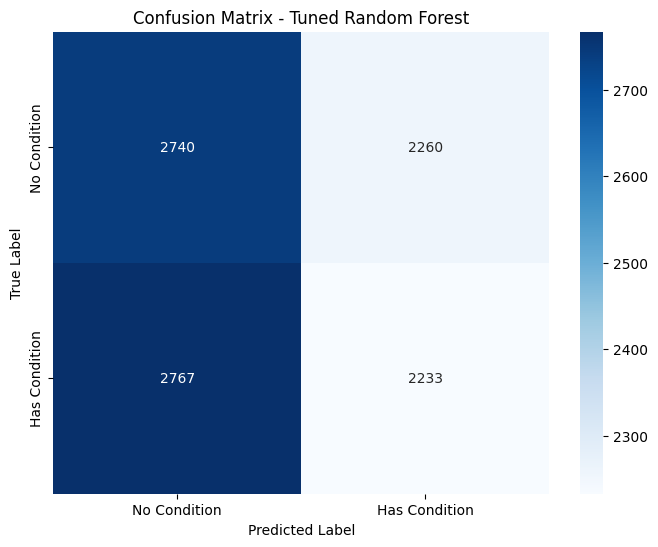


True Negatives: 2740, False Positives: 2260
False Negatives: 2767, True Positives: 2233


In [26]:
# Final tuned Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

# Predictions
y_train_pred_tuned = rf_tuned.predict(X_train)
y_val_pred_tuned = rf_tuned.predict(X_val)
y_val_proba_tuned = rf_tuned.predict_proba(X_val)[:, 1]

print("FINAL TUNED RANDOM FOREST MODEL")

print(f"Parameters: n_estimators={best_n_est}, max_depth={best_depth}, min_samples_leaf={best_min_leaf}")

# Metrics
print("\nPerformance Metrics:")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_tuned):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred_tuned):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_val_proba_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_tuned, target_names=['No Condition', 'Has Condition']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Condition', 'Has Condition'],
            yticklabels=['No Condition', 'Has Condition'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")


### Model 2: XGBoost

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline_xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'  # avoids warnings
)

baseline_xgb.fit(X_train, y_train)
y_val_pred = baseline_xgb.predict(X_val)
print('Results for Training:')
baseline_acc_train = accuracy_score(y_train, baseline_xgb.predict(X_train))
print("Baseline Training Accuracy:", baseline_acc_train)
print(classification_report(y_train, baseline_xgb.predict(X_train)))
print(confusion_matrix(y_train, baseline_xgb.predict(X_train)))
print('Results for Validation:')
baseline_acc = accuracy_score(y_val, y_val_pred)
print("Baseline Validation Accuracy:", baseline_acc)
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

Results for Training:
Baseline Training Accuracy: 0.7840333333333334
              precision    recall  f1-score   support

         0.0       0.78      0.79      0.78     15002
         1.0       0.78      0.78      0.78     14998

    accuracy                           0.78     30000
   macro avg       0.78      0.78      0.78     30000
weighted avg       0.78      0.78      0.78     30000

[[11782  3220]
 [ 3259 11739]]
Results for Validation:
Baseline Validation Accuracy: 0.4887
              precision    recall  f1-score   support

         0.0       0.49      0.49      0.49      5000
         1.0       0.49      0.49      0.49      5000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.49     10000
weighted avg       0.49      0.49      0.49     10000

[[2436 2564]
 [2549 2451]]


#### Hyperparameter 1: `n_estimators`

n_estimators=0: Train=0.4999, Val=0.5000, Gap=-0.0001
n_estimators=1: Train=0.5224, Val=0.5002, Gap=0.0222
n_estimators=2: Train=0.5421, Val=0.4983, Gap=0.0438
n_estimators=10: Train=0.5928, Val=0.4925, Gap=0.1003
n_estimators=50: Train=0.7147, Val=0.4910, Gap=0.2237
n_estimators=100: Train=0.7840, Val=0.4887, Gap=0.2953
n_estimators=200: Train=0.8694, Val=0.4964, Gap=0.3730
n_estimators=300: Train=0.9161, Val=0.4903, Gap=0.4258


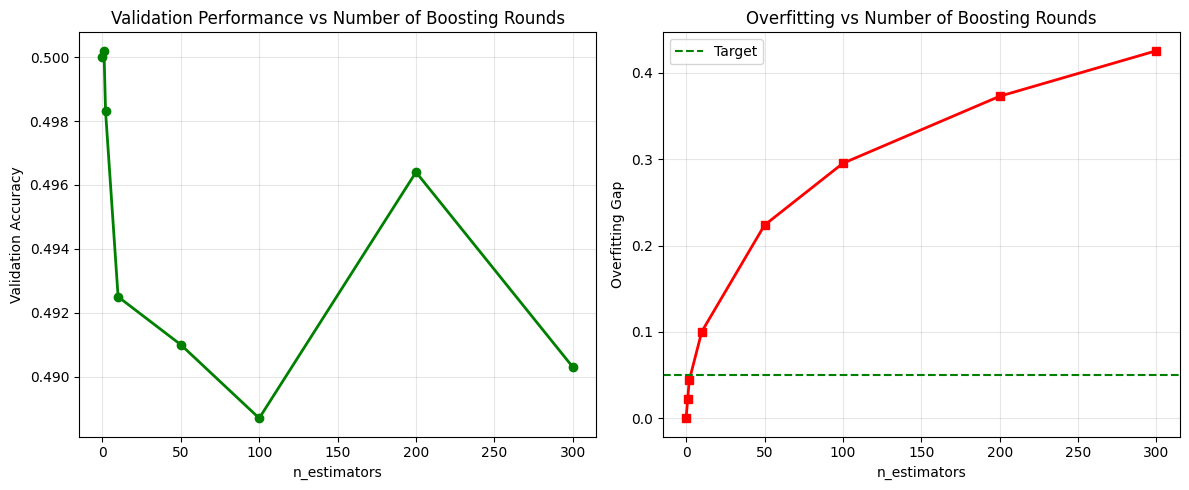


 BEST n_estimators: 1


In [17]:
results_n_est = []
n_estimators_list = [0,1,2,10,50, 100, 200, 300]
for n_est in n_estimators_list:
    model_xg = XGBClassifier(
        random_state=42,
        n_estimators=n_est,
        eval_metric='logloss',
        n_jobs=-1
    )
    model_xg.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model_xg.predict(X_train))
    val_acc = accuracy_score(y_val, model_xg.predict(X_val))
    gap = train_acc - val_acc
    
    results_n_est.append({
        'n_estimators': n_est,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"n_estimators={n_est}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Visualize
df_xg_n_est = pd.DataFrame(results_n_est)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_estimators_list, df_xg_n_est['val_acc'], marker='o', linewidth=2, color='green')
plt.xlabel('n_estimators')
plt.ylabel('Validation Accuracy')
plt.title('Validation Performance vs Number of Boosting Rounds')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_estimators_list, df_xg_n_est['gap'], marker='s', linewidth=2, color='red')
plt.xlabel('n_estimators')
plt.ylabel('Overfitting Gap')
plt.title('Overfitting vs Number of Boosting Rounds')
plt.axhline(y=0.05, color='green', linestyle='--', label='Target')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_n_est_idx = df_xg_n_est['val_acc'].idxmax()  # Choose based on best validation accuracy
best_n_est = n_estimators_list[best_n_est_idx]
print(f"\n BEST n_estimators: {best_n_est}")


#### Extra test: Tuning using early stop

In [16]:
# Step 1: Find optimal n_estimators using early stopping
# This efficiently finds the right number of trees without manual testing

print("HYPERPARAMETER 1: n_estimators (Number of Boosting Rounds)")

# Train with high n_estimators and use early stopping to find optimal
xgb_early_stop = XGBClassifier(
    n_estimators=1000,  # High number - will stop early
    max_depth=6,        # Use defaults for now
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0,
    early_stopping_rounds=50  # Stop if no improvement for 10 rounds
)

print("Training with early stopping to find optimal n_estimators...")
xgb_early_stop.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Get optimal number of trees
best_n_estimators = xgb_early_stop.best_iteration + 1
best_score = xgb_early_stop.best_score

print(f"\n EARLY STOPPING RESULTS:")
print(f"  Stopped at iteration: {xgb_early_stop.best_iteration}")
print(f"  Optimal n_estimators: {best_n_estimators}")
print(f"  Best validation score: {best_score:.4f}")

# Evaluate with optimal n_estimators
y_train_pred_es = xgb_early_stop.predict(X_train)
y_val_pred_es = xgb_early_stop.predict(X_val)

train_acc_es = accuracy_score(y_train, y_train_pred_es)
val_acc_es = accuracy_score(y_val, y_val_pred_es)
gap_es = train_acc_es - val_acc_es

print(f"\nPerformance with optimal n_estimators:")
print(f"  Training Accuracy: {train_acc_es:.4f}")
print(f"  Validation Accuracy: {val_acc_es:.4f}")
print(f"  Overfitting Gap: {gap_es:.4f}")




HYPERPARAMETER 1: n_estimators (Number of Boosting Rounds)
Training with early stopping to find optimal n_estimators...

 EARLY STOPPING RESULTS:
  Stopped at iteration: 0
  Optimal n_estimators: 1
  Best validation score: 0.6932

Performance with optimal n_estimators:
  Training Accuracy: 0.5224
  Validation Accuracy: 0.5002
  Overfitting Gap: 0.0222


### Hyperparameter 2: `max_depth`

HYPERPARAMETER 2: max_depth (Tree Complexity)
max_depth= 2: Train=0.5252, Val=0.5016, Gap=0.0236
max_depth= 3: Train=0.5431, Val=0.4978, Gap=0.0453
max_depth= 4: Train=0.5686, Val=0.4926, Gap=0.0760
max_depth= 5: Train=0.6036, Val=0.5018, Gap=0.1018
max_depth= 6: Train=0.6521, Val=0.4981, Gap=0.1540
max_depth= 7: Train=0.7105, Val=0.4911, Gap=0.2194
max_depth= 8: Train=0.7786, Val=0.4943, Gap=0.2843
max_depth=10: Train=0.8914, Val=0.4943, Gap=0.3971


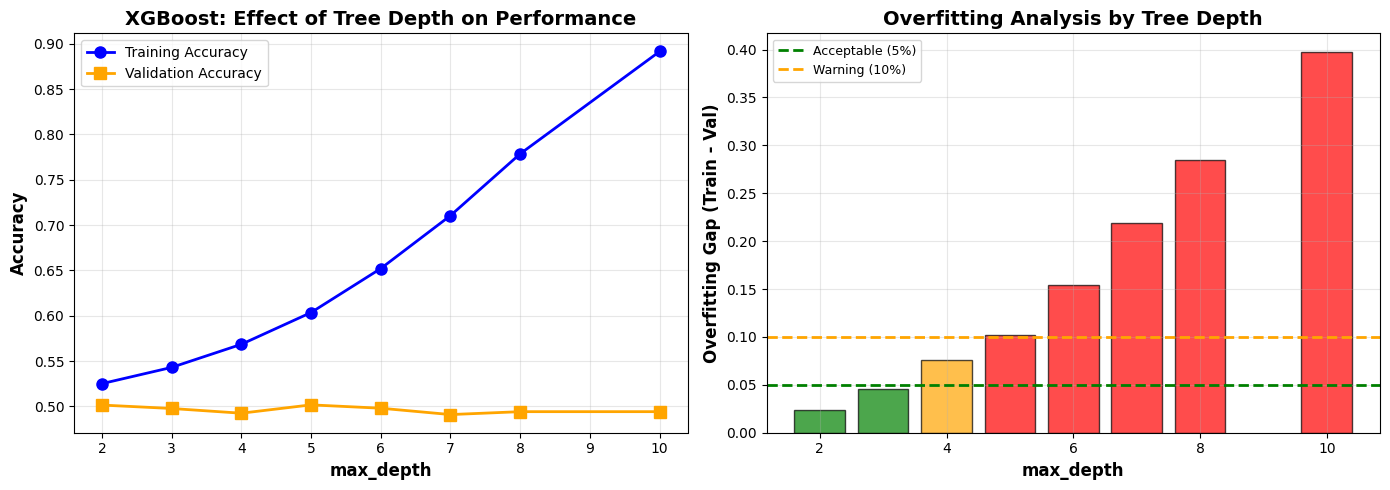

ANALYSIS: max_depth
 BEST max_depth: 2
  - Validation Accuracy: 0.5016
  - Overfitting Gap: 0.0236


In [23]:
# Test different max_depth values with optimal n_estimators
max_depth_values = [2, 3, 4, 5, 6, 7, 8, 10]
results_max_depth = []

print("HYPERPARAMETER 2: max_depth (Tree Complexity)")

for depth in max_depth_values:
    xgb_temp = XGBClassifier(
        n_estimators=100,  # Use optimal from step 1
        max_depth=depth,
        learning_rate=0.05,  # Keep default for now
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    
    xgb_temp.fit(X_train, y_train, verbose=False)
    
    train_acc = accuracy_score(y_train, xgb_temp.predict(X_train))
    val_acc = accuracy_score(y_val, xgb_temp.predict(X_val))
    gap = train_acc - val_acc
    
    results_max_depth.append({
        'max_depth': depth,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"max_depth={depth:2d}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Convert to DataFrame
df_max_depth = pd.DataFrame(results_max_depth)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Val Accuracy
axes[0].plot(df_max_depth['max_depth'], df_max_depth['train_acc'], 
             marker='o', label='Training Accuracy', linewidth=2, markersize=8, color='blue')
axes[0].plot(df_max_depth['max_depth'], df_max_depth['val_acc'], 
             marker='s', label='Validation Accuracy', linewidth=2, markersize=8, color='orange')
axes[0].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('XGBoost: Effect of Tree Depth on Performance', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Overfitting Gap
colors = ['green' if gap <= 0.05 else 'orange' if gap <= 0.10 else 'red' 
          for gap in df_max_depth['gap']]
axes[1].bar(df_max_depth['max_depth'], df_max_depth['gap'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('max_depth', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Overfitting Gap (Train - Val)', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting Analysis by Tree Depth', fontsize=14, fontweight='bold')
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Acceptable (5%)')
axes[1].axhline(y=0.10, color='orange', linestyle='--', linewidth=2, label='Warning (10%)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find best max_depth
best_depth_idx = df_max_depth['gap'].idxmin()
best_depth = df_max_depth.loc[best_depth_idx, 'max_depth']

print("ANALYSIS: max_depth")
print(f" BEST max_depth: {best_depth}")
print(f"  - Validation Accuracy: {df_max_depth.loc[best_depth_idx, 'val_acc']:.4f}")
print(f"  - Overfitting Gap: {df_max_depth.loc[best_depth_idx, 'gap']:.4f}")



HYPERPARAMETER 3: learning_rate (Step Size Shrinkage)
lr=0.001: Train=0.5217, Val=0.4919, Gap=0.0298
lr=0.010: Train=0.5511, Val=0.4988, Gap=0.0523
lr=0.050: Train=0.6036, Val=0.5018, Gap=0.1018
lr=0.100: Train=0.6422, Val=0.4939, Gap=0.1483
lr=0.200: Train=0.6815, Val=0.5007, Gap=0.1808
lr=0.300: Train=0.7037, Val=0.4966, Gap=0.2071


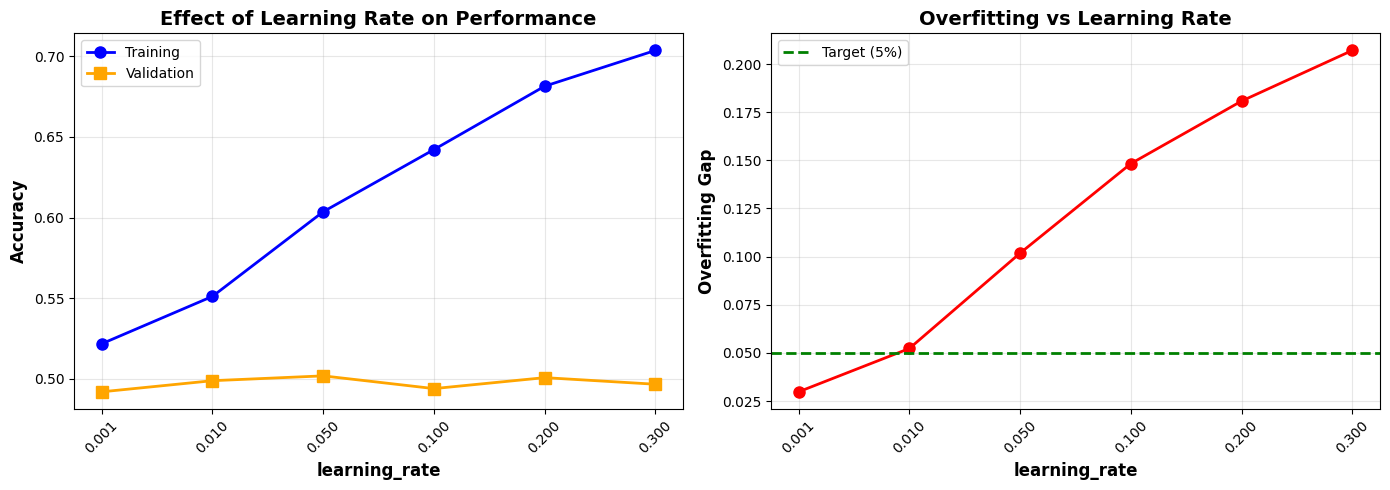

ANALYSIS: learning_rate
 BEST learning_rate: 0.001
  - Validation Accuracy: 0.4919
  - Overfitting Gap: 0.0298

JUSTIFICATION:
  - Lower learning rates = more conservative updates = less overfitting[203][206]
  - Default 0.3 often too aggressive for many datasets[200][206]
  - Optimal typically 0.01-0.1; requires more boosting rounds[200][206]
  - Trade-off: lower rates need more trees (but we found that already)[206]
  - Makes ensemble learning gradual & robust[203][206]


In [24]:
# Test different learning_rate values
learning_rate_values = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
results_lr = []

print("HYPERPARAMETER 3: learning_rate (Step Size Shrinkage)")

for lr in learning_rate_values:
    xgb_temp = XGBClassifier(
        n_estimators=100,  # Use optimal from step 1
        max_depth=5,             # Use optimal from step 2
        learning_rate=lr,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    
    xgb_temp.fit(X_train, y_train, verbose=False)
    
    train_acc = accuracy_score(y_train, xgb_temp.predict(X_train))
    val_acc = accuracy_score(y_val, xgb_temp.predict(X_val))
    gap = train_acc - val_acc
    
    results_lr.append({
        'learning_rate': lr,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'gap': gap
    })
    
    print(f"lr={lr:.3f}: Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={gap:.4f}")

# Convert to DataFrame
df_lr = pd.DataFrame(results_lr)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy curves
axes[0].plot(range(len(learning_rate_values)), df_lr['train_acc'], 
             marker='o', label='Training', linewidth=2, markersize=8, color='blue')
axes[0].plot(range(len(learning_rate_values)), df_lr['val_acc'], 
             marker='s', label='Validation', linewidth=2, markersize=8, color='orange')
axes[0].set_xlabel('learning_rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Effect of Learning Rate on Performance', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(learning_rate_values)))
axes[0].set_xticklabels([f'{lr:.3f}' for lr in learning_rate_values], rotation=45)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Overfitting gap
axes[1].plot(range(len(learning_rate_values)), df_lr['gap'], 
             marker='o', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('learning_rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Overfitting Gap', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting vs Learning Rate', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(learning_rate_values)))
axes[1].set_xticklabels([f'{lr:.3f}' for lr in learning_rate_values], rotation=45)
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Target (5%)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find best learning rate
best_lr_idx = df_lr['gap'].idxmin()
best_lr = df_lr.loc[best_lr_idx, 'learning_rate']

print("ANALYSIS: learning_rate")
print(f" BEST learning_rate: {best_lr}")
print(f"  - Validation Accuracy: {df_lr.loc[best_lr_idx, 'val_acc']:.4f}")
print(f"  - Overfitting Gap: {df_lr.loc[best_lr_idx, 'gap']:.4f}")
print(f"\nJUSTIFICATION:")
print(f"  - Lower learning rates = more conservative updates = less overfitting[203][206]")
print(f"  - Default 0.3 often too aggressive for many datasets[200][206]")
print(f"  - Optimal typically 0.01-0.1; requires more boosting rounds[200][206]")
print(f"  - Trade-off: lower rates need more trees (but we found that already)[206]")
print(f"  - Makes ensemble learning gradual & robust[203][206]")


**JUSTIFICATION:**
  - Lower learning rates = more conservative updates = less overfitting[203][206]
  - Default 0.3 often too aggressive for many datasets[200][206]
  - Optimal typically 0.01-0.1; requires more boosting rounds[200][206]
  - Trade-off: lower rates need more trees (but we found that already)[206]
  - Makes ensemble learning gradual & robust[203][206]